# EDA2

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

# 1. Data Exploration and Preprocessing:

In [91]:
data=pd.read_csv('adult_with_headers.csv')

In [92]:
data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [94]:
data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [95]:
data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [96]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [97]:
numaric_cols=data.select_dtypes(include=[int,float]).columns

In [98]:
numaric_cols

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [99]:
stdscaler=StandardScaler()
minmax=MinMaxScaler()

In [100]:
dfstd=stdscaler.fit_transform(data[numaric_cols])
dfstd=pd.DataFrame(dfstd,columns=numaric_cols)
dfmm=minmax.fit_transform(data[numaric_cols])
dfmm=pd.DataFrame(dfmm,columns=numaric_cols)

In [101]:
dfstd

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429
...,...,...,...,...,...,...
32556,-0.849080,0.639741,0.746039,-0.145920,-0.21666,-0.197409
32557,0.103983,-0.335433,-0.420060,-0.145920,-0.21666,-0.035429
32558,1.423610,-0.358777,-0.420060,-0.145920,-0.21666,-0.035429
32559,-1.215643,0.110960,-0.420060,-0.145920,-0.21666,-1.655225


In [102]:
dfmm

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.021740,0.0,0.397959
1,0.452055,0.048238,0.800000,0.000000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.000000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.000000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.000000,0.0,0.397959
...,...,...,...,...,...,...
32556,0.136986,0.166404,0.733333,0.000000,0.0,0.377551
32557,0.315068,0.096500,0.533333,0.000000,0.0,0.397959
32558,0.561644,0.094827,0.533333,0.000000,0.0,0.397959
32559,0.068493,0.128499,0.533333,0.000000,0.0,0.193878


In [103]:
dfstd.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04
mean,-2.705915e-17,-1.001625e-16,1.471887e-16,1.309314e-17,1.016900e-16,-1.549355e-17
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.582206e+00,-1.681631e+00,-3.529656e+00,-1.459205e-01,-2.166595e-01,-3.194030e+00
25%,-7.757679e-01,-6.816910e-01,-4.200596e-01,-1.459205e-01,-2.166595e-01,-3.542945e-02
50%,-1.159546e-01,-1.082193e-01,-3.136003e-02,-1.459205e-01,-2.166595e-01,-3.542945e-02
75%,6.904838e-01,4.478765e-01,7.460392e-01,-1.459205e-01,-2.166595e-01,3.695194e-01
max,3.769612e+00,1.226856e+01,2.300838e+00,1.339458e+01,1.059351e+01,4.742967e+00


In [104]:
dfmm.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,0.295639,0.120545,0.605379,0.010777,0.020042,0.402423
std,0.186855,0.071685,0.171515,0.073854,0.092507,0.125994
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.071679,0.533333,0.000000,0.000000,0.397959
50%,0.273973,0.112788,0.600000,0.000000,0.000000,0.397959
75%,0.424658,0.152651,0.733333,0.000000,0.000000,0.448980
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Discuss the scenarios where each scaling technique is preferred and why.
##### Standardization:
    Preferred when data is normally distributed or when the algorithm assumes a Gaussian distribution.
##### Normalization (Min-Max Scaling):
    Preferred when data needs to be bounded within a specific range (e.g., [0, 1] or [-1, 1]).

# 2. Encoding Techniques:

In [105]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [106]:
categorical_cols=data.select_dtypes(include='object').columns
categorical_cols

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [107]:
for col in categorical_cols:
    b=data[col].unique()
    print(f'{col} had {b}','\n')

workclass had [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked'] 

education had [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th'] 

marital_status had [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed'] 

occupation had [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv'] 

relationship had [' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative'] 

race had [' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other'] 

sex had [' Male' ' Female'] 

native_country had [

In [108]:
onehot=OneHotEncoder()

In [109]:
dummies = pd.get_dummies(data[['sex','income']],dtype=int)

In [110]:
dummies

,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0,1,1,0
1,0,1,1,0
2,0,1,1,0
3,0,1,1,0
4,1,0,1,0
...,...,...,...,...
32556,1,0,1,0
32557,0,1,0,1
32558,1,0,1,0
32559,0,1,1,0


In [111]:
label=LabelEncoder()

In [112]:
data['education'] = label.fit_transform(data['education'])
data['workclass'] = label.fit_transform(data['workclass'])
data['marital_status'] = label.fit_transform(data['marital_status'])
data['occupation'] = label.fit_transform(data['occupation'])
data['relationship'] = label.fit_transform(data['relationship'])
data['race'] = label.fit_transform(data['race'])
data['native_country'] = label.fit_transform(data['native_country'])

In [113]:
data.drop(data[['sex','income']],axis=1,inplace=True)

In [114]:
data=data.join(dummies,how='right')

In [115]:
data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,0,1,1,0
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0,1,1,0
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0,1,1,0
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0,1,1,0
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,38,39,1,0,1,0
32557,40,4,154374,11,9,2,7,0,4,0,0,40,39,0,1,0,1
32558,58,4,151910,11,9,6,1,4,4,0,0,40,39,1,0,1,0
32559,22,4,201490,11,9,4,1,3,4,0,0,20,39,0,1,1,0


In [116]:
data.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
count,32561.000000,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,3.868892,1.897784e+05,10.298210,10.080679,2.611836,6.572740,1.446362,3.665858,1077.648844,87.303830,40.437456,36.718866,0.330795,0.669205,0.759190,0.240810
std,13.640433,1.455960,1.055500e+05,3.870264,2.572720,1.506222,4.228857,1.606771,0.848806,7385.292085,402.960219,12.347429,7.823782,0.470506,0.470506,0.427581,0.427581
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,40.000000,39.000000,0.000000,0.000000,1.000000,0.000000
50%,37.000000,4.000000,1.783560e+05,11.000000,10.000000,2.000000,7.000000,1.000000,4.000000,0.000000,0.000000,40.000000,39.000000,0.000000,1.000000,1.000000,0.000000
75%,48.000000,4.000000,2.370510e+05,12.000000,12.000000,4.000000,10.000000,3.000000,4.000000,0.000000,0.000000,45.000000,39.000000,1.000000,1.000000,1.000000,0.000000
max,90.000000,8.000000,1.484705e+06,15.000000,16.000000,6.000000,14.000000,5.000000,4.000000,99999.000000,4356.000000,99.000000,41.000000,1.000000,1.000000,1.000000,1.000000


In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int64
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  int64
 6   occupation      32561 non-null  int64
 7   relationship    32561 non-null  int64
 8   race            32561 non-null  int64
 9   capital_gain    32561 non-null  int64
 10  capital_loss    32561 non-null  int64
 11  hours_per_week  32561 non-null  int64
 12  native_country  32561 non-null  int64
 13  sex_ Female     32561 non-null  int64
 14  sex_ Male       32561 non-null  int64
 15  income_ <=50K   32561 non-null  int64
 16  income_ >50K    32561 non-null  int64
dtypes: int64(17)
memory usage: 4.2 MB


### One-Hot Encoding vs. Label Encoding: Pros and Cons

When dealing with categorical features in machine learning, encoding them into numerical representations is necessary. Two common techniques are One-Hot Encoding and Label Encoding, each with its own advantages and disadvantages.

#### Label Encoding

**Pros:**

*   It is straightforward to implement and requires less memory compared to one-hot encoding, especially for features with a high number of unique categories.
*   Models can process a single numerical column faster than multiple binary columns.

**Cons:**

*  Assigning arbitrary numerical values (e.g., 0, 1, 2) to categories implies an ordinal relationship, even if none exists. For example, if 'red' is 0, 'green' is 1, and 'blue' is 2, a model might incorrectly infer that 'blue' is 'greater' than 'green'. This can negatively impact model performance, particularly with algorithms that calculate distances or assume continuous input (e.g., linear regression, SVMs, k-NN).
*  Due to the ordinality issue, it's generally not recommended for nominal categorical features (categories without a natural order).

#### One-Hot Encoding

**Pros:**

*  It creates new binary columns for each category, preventing the model from assuming an arbitrary ordinal relationship between categories. Each category is treated independently.
*  Ideal for nominal categorical features where there is no inherent order.

**Cons:**

*  For features with many unique categories, it can lead to a large number of new columns (the "curse of dimensionality"). This can increase memory usage, slow down training, and potentially lead to multicollinearity if not handled correctly (e.g., by dropping one of the dummy variables).
*  The new columns will mostly contain zeros, leading to sparse matrices, which can be inefficient for some algorithms.


**In summary, the choice between Label Encoding and One-Hot Encoding largely depends on the nature of the categorical data (ordinal vs. nominal) and the type of machine learning model we plan to use.**

# 3. Feature Engineering:

In [118]:
# Create new features
data['capital-gain-minus-loss'] = data['capital_gain'] - data['capital_loss']
data['age_squared'] = data['age'] ** 2

In [119]:
data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,capital-gain-minus-loss,age_squared
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,0,1,1,0,2174,1521
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0,1,1,0,0,2500
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0,1,1,0,0,1444
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0,1,1,0,0,2809
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,1,0,1,0,0,784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,38,39,1,0,1,0,0,729
32557,40,4,154374,11,9,2,7,0,4,0,0,40,39,0,1,0,1,0,1600
32558,58,4,151910,11,9,6,1,4,4,0,0,40,39,1,0,1,0,0,3364
32559,22,4,201490,11,9,4,1,3,4,0,0,20,39,0,1,1,0,0,484


In [120]:
data['capital-gain_log'] = np.log1p(data['capital_gain'])

In [121]:
data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,capital-gain-minus-loss,age_squared,capital-gain_log
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,0,1,1,0,2174,1521,7.684784
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0,1,1,0,0,2500,0.000000
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0,1,1,0,0,1444,0.000000
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0,1,1,0,0,2809,0.000000
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,1,0,1,0,0,784,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,38,39,1,0,1,0,0,729,0.000000
32557,40,4,154374,11,9,2,7,0,4,0,0,40,39,0,1,0,1,0,1600,0.000000
32558,58,4,151910,11,9,6,1,4,4,0,0,40,39,1,0,1,0,0,3364,0.000000
32559,22,4,201490,11,9,4,1,3,4,0,0,20,39,0,1,1,0,0,484,0.000000


# 4. Feature Selection:

In [122]:
from sklearn.ensemble import IsolationForest

In [123]:
ift=IsolationForest(random_state=10,contamination=0.1)

In [124]:
ift.fit(data)

IsolationForest(contamination=0.1, random_state=10)

In [125]:
outliers=pd.DataFrame(ift.predict(data))

In [126]:
outliers.columns = ['outliers']

In [127]:
data=data.join(outliers,how='right')

In [128]:
data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,...,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,capital-gain-minus-loss,age_squared,capital-gain_log,outliers
0,39,7,77516,9,13,4,1,1,4,2174,...,40,39,0,1,1,0,2174,1521,7.684784,1
1,50,6,83311,9,13,2,4,0,4,0,...,13,39,0,1,1,0,0,2500,0.000000,1
2,38,4,215646,11,9,0,6,1,4,0,...,40,39,0,1,1,0,0,1444,0.000000,1
3,53,4,234721,1,7,2,6,0,2,0,...,40,39,0,1,1,0,0,2809,0.000000,1
4,28,4,338409,9,13,2,10,5,2,0,...,40,5,1,0,1,0,0,784,0.000000,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,...,38,39,1,0,1,0,0,729,0.000000,1
32557,40,4,154374,11,9,2,7,0,4,0,...,40,39,0,1,0,1,0,1600,0.000000,1
32558,58,4,151910,11,9,6,1,4,4,0,...,40,39,1,0,1,0,0,3364,0.000000,1
32559,22,4,201490,11,9,4,1,3,4,0,...,20,39,0,1,1,0,0,484,0.000000,1


In [129]:
data[data['outliers']==-1]

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,...,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,capital-gain-minus-loss,age_squared,capital-gain_log,outliers
4,28,4,338409,9,13,2,10,5,2,0,...,40,5,1,0,1,0,0,784,0.000000,-1
8,31,4,45781,12,14,4,10,1,4,14084,...,50,39,1,0,0,1,14084,961,9.552866,-1
27,54,0,180211,15,10,2,0,0,1,0,...,60,35,0,1,0,1,0,2916,0.000000,-1
52,47,4,51835,14,15,2,10,5,4,0,...,60,16,1,0,0,1,-1902,2209,0.000000,-1
61,32,0,293936,5,4,3,0,1,4,0,...,40,0,0,1,1,0,0,1024,0.000000,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32538,38,4,139180,9,13,0,10,4,2,15020,...,45,39,1,0,0,1,15020,1444,9.617205,-1
32539,71,0,287372,10,16,2,0,0,4,0,...,10,39,0,1,0,1,0,5041,0.000000,-1
32545,39,2,111499,7,12,2,1,5,4,0,...,20,39,1,0,0,1,0,1521,0.000000,-1
32548,65,6,99359,14,15,4,10,1,4,1086,...,60,39,0,1,1,0,1086,4225,6.991177,-1


In [130]:
!pip install ppscore

In [131]:
import ppscore as pps

In [132]:
pps.score(data,'age','income_ >50K')

{'x': 'age',
 'y': 'income_ >50K',
 'ppscore': 0,
 'case': 'regression',
 'is_valid_score': True,
 'metric': 'mean absolute error',
 'baseline_score': 0.2424,
 'model_score': np.float64(0.32837761728313286),
 'model': DecisionTreeRegressor()}

In [133]:
pps.matrix(data)

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.000000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.742600,0.875681,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,75872.186200,77535.141544,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.759000,2.806164,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.853000,1.898306,DecisionTreeRegressor()
...,...,...,...,...,...,...,...,...,...
436,outliers,income_ >50K,0.0,regression,True,mean absolute error,0.242400,0.343314,DecisionTreeRegressor()
437,outliers,capital-gain-minus-loss,0.0,regression,True,mean absolute error,1188.826600,1535.460754,DecisionTreeRegressor()
438,outliers,age_squared,0.0,regression,True,mean absolute error,897.468600,907.468831,DecisionTreeRegressor()
439,outliers,capital-gain_log,0.0,regression,True,mean absolute error,0.714858,1.021794,DecisionTreeRegressor()


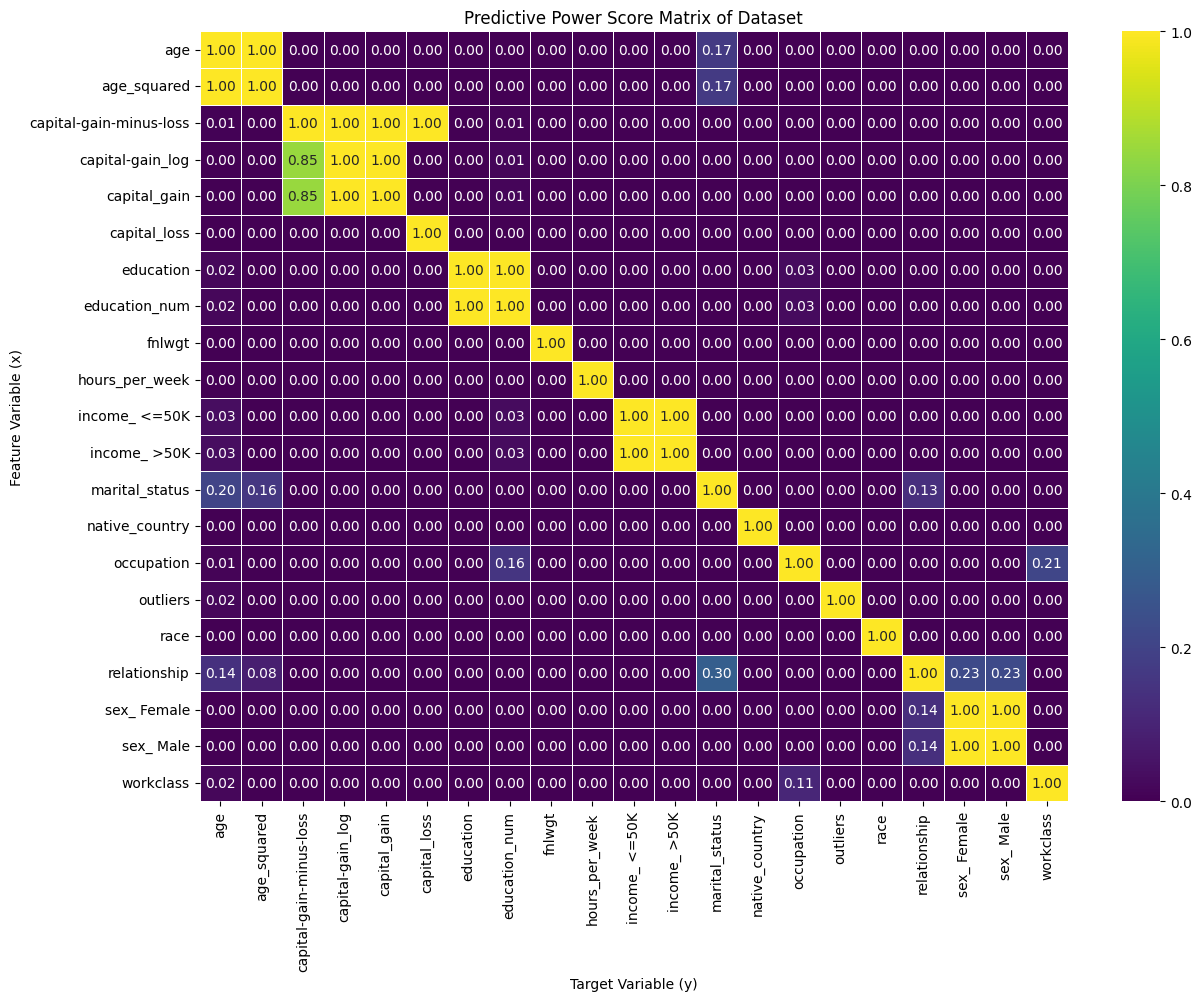

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the PPS matrix (already done in previous cell, but re-running for completeness)
pps_matrix = pps.matrix(data)

# Create a pivot table for the heatmap
pps_pivot = pps_matrix.pivot(index='x', columns='y', values='ppscore')

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pps_pivot, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Predictive Power Score Matrix of Dataset')
plt.xlabel('Target Variable (y)')
plt.ylabel('Feature Variable (x)')
plt.show()

The heatmap above visualizes the Predictive Power Score (PPS) between all pairs of variables in the dataset. A higher PPS value (closer to 1) indicates that the feature variable (`x`) is a strong predictor of the target variable (`y`). A value of 0 indicates no predictive power. The diagonal elements are 1 because a variable perfectly predicts itself.

### PPS vs. Correlation:

Both Predictive Power Score (PPS) and correlation measure relationships between variables, but they do so in fundamentally different ways.

#### Correlation:

*   **Measures linear relationships:** Correlation coefficients quantify the strength and direction of linear relationships between two numerical variables. If the relationship is non-linear, correlation might report a low value even if a strong relationship exists.
*   **Symmetric:** The correlation between X and Y is the same as the correlation between Y and X. It doesn't imply directionality or causality.
*   **Limited to numerical data:** Traditional correlation coefficients are designed for numerical variables. While some methods extend to categorical data (e.g., Cramer's V), they are not as universally applied or intuitive as for numerical pairs.
*   **Range:** Typically ranges from -1 (perfect negative linear relationship) to +1 (perfect positive linear relationship), with 0 indicating no linear relationship.

#### Predictive Power Score (PPS):

*   **Measures non-linear and linear relationships:** PPS assesses the ability of one variable to predict another, using a data-driven predictive model (like a decision tree). This means it can detect non-linear relationships that traditional correlation would miss.
*   **Asymmetric:** The PPS of X predicting Y is generally *not* the same as the PPS of Y predicting X. This asymmetry is crucial as it indicates the directional predictive power.
*   **Handles various data types:** PPS can work with any data type (numerical, categorical) for both the feature and target variables. It adapts the prediction model based on the data types involved.
*   **Range:** Ranges from 0 (no predictive power) to 1 (perfect predictive power).

#### In the context of this dataset:

The PPS heatmap above shows predictive power. For example:

*   `age` and `age_squared` have very high PPS scores for predicting each other (close to 1). This is expected as `age_squared` is directly derived from `age`.
*   Similarly, `capital_gain`, `capital_loss`, `capital-gain-minus-loss`, and `capital-gain_log` show strong predictive power among themselves due to their direct mathematical relationships.
*   Look at `income_<=50K` and `income_>50K`. They predict each other with 1.00, as they are essentially inverse representations of the same binary outcome.
*   Some variables have a low correlation with `income` but a higher PPS, indicating a non-linear predictive relationship.

**Conclusion:** PPS is a more robust and comprehensive measure of relationships, especially when dealing with complex datasets that might have non-linear dependencies or mixed data types, as it focuses on predictive strength rather than just linear association. It can uncover hidden predictive patterns that correlation might overlook.